## Analyzing the Similariry Globality Curves

In [19]:
import json
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parents[1]))
from paths import resources_path

In [20]:
def load_sweep_data(metric_name, seeds, layers, results_base="results/pca_deletion"):
    """
    Load sweep data for specified metric, seeds, and layers.
    
    Args:
        metric_name: name of metric (e.g., 'softmax_rwka_auc')
        seeds: list of seed numbers (e.g., [1, 2, 3])
        layers: list of layer indices (e.g., [0, 1, 2])
        results_base: base path for results (relative to resources_path)
    
    Returns:
        dict: indexed by (seed, layer) containing a dict with:
              - param_values: list of parameter values swept
              - param_name: name of parameter (e.g., 'temperature')
              - sweeps_by_dims: dict indexed by dims_deleted with scores
    """
    results_path = resources_path / results_base
    
    sweeps_dir = results_path / "sweeps"
    
    if not sweeps_dir.exists():
        raise ValueError(f"No sweeps directory found at {sweeps_dir}")
    
    sweep_data = {}
    
    for seed in seeds:
        for layer in layers:
            # Look for JSON files matching this seed and layer (including dims_deleted suffix)
            pattern = f"{metric_name}__base__s{seed}__l{layer}__vs__base__s{seed}__l{layer}*.json"
            matching_files = sorted(sweeps_dir.glob(pattern))
            
            for sweep_file in matching_files:
                if sweep_file.exists():
                    with open(sweep_file, 'r') as f:
                        data = json.load(f)
                        
                    param_name = data.get('param_name')
                    param_values = data.get('param_values', [])
                    metadata = data.get('metadata', {})
                    if 'dims_deleted' in metadata and '__d' not in sweep_file.stem:
                        continue
                    scores = data.get('scores', [])
                    dims_deleted = metadata.get('dims_deleted', 0)
                    
                    key = (seed, layer)
                    if key not in sweep_data:
                        sweep_data[key] = {
                            'param_name': param_name,
                            'param_values': param_values,
                            'sweeps_by_dims': {}
                        }
                    
                    sweep_data[key]['sweeps_by_dims'][dims_deleted] = scores
                else:
                    print(f"Warning: File not found for seed {seed}, layer {layer}: {pattern}")
    
    return sweep_data


print("Sweep loader function defined.")

Sweep loader function defined.


In [21]:
def plot_sweeps(sweep_data, seed, layer, title=None):
    """
    Plot score vs param value for different dims_deleted values.
    
    Args:
        sweep_data: output from load_sweep_data()
        seed: which seed to plot
        layer: which layer to plot
        title: optional custom title
    """
    key = (seed, layer)
    if key not in sweep_data:
        print(f"No data for seed {seed}, layer {layer}")
        return
    
    data = sweep_data[key]
    param_name = data['param_name']
    param_values = np.array(data['param_values'])
    sweeps_by_dims = data['sweeps_by_dims']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Sort by dims_deleted for cleaner legend
    sorted_dims = sorted(sweeps_by_dims.keys())
    
    # Use colormap for different deletion levels
    cmap = plt.colormaps.get_cmap('viridis').resampled(max(len(sorted_dims), 1))
    
    for idx, dims_del in enumerate(sorted_dims):
        scores = np.array(sweeps_by_dims[dims_del])
        ax.plot(param_values, scores, marker='o', label=f'dims_deleted={dims_del}', 
                color=cmap(idx), linewidth=2, markersize=6)
    
    ax.set_xlabel(f'{param_name} (sweep parameter)', fontsize=12)
    ax.set_ylabel('Similarity Score', fontsize=12)
    ax.set_title(title or f'Similarity Sweeps: Seed {seed}, Layer {layer}', fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax


print("Plot function defined.")

Plot function defined.


In [22]:
def is_logscale_sweep(param_values):
    """
    Detect if parameter values are log-scaled by checking if ratios are consistent.
    Log-spaced values have constant multiplicative ratios.
    """
    if len(param_values) < 3:
        return False
    
    param_values = np.array(param_values)
    # Compute ratios between consecutive values
    ratios = param_values[1:] / param_values[:-1]
    # Check if ratios are approximately constant (within tolerance)
    ratio_std = np.std(ratios)
    ratio_mean = np.mean(ratios)
    
    # If standard deviation is small relative to mean, it's likely log-spaced
    return ratio_std / ratio_mean < 0.05 and ratio_mean > 1.01


def plot_all_dims_same_figure(sweep_data, seed, layer, title=None):
    """
    Plot all dims_deleted on the SAME figure for a given seed and layer.
    Automatically detects logscale and applies it to x-axis if needed.
    
    Args:
        sweep_data: output from load_sweep_data()
        seed: which seed to plot
        layer: which layer to plot
        title: optional custom title
    """
    key = (seed, layer)
    if key not in sweep_data:
        print(f"No data for seed {seed}, layer {layer}")
        return
    
    data = sweep_data[key]
    param_name = data['param_name']
    param_values = np.array(data['param_values'])
    sweeps_by_dims = data['sweeps_by_dims']
    
    # Detect if sweep is logscale
    use_logscale = is_logscale_sweep(param_values)
    
    fig, ax = plt.subplots(figsize=(13, 6))
    
    # Sort by dims_deleted for cleaner legend
    sorted_dims = sorted(sweeps_by_dims.keys())
    
    # Use colormap for different deletion levels
    cmap = plt.colormaps.get_cmap('viridis').resampled(max(len(sorted_dims), 1))
    
    for idx, dims_del in enumerate(sorted_dims):
        scores = np.array(sweeps_by_dims[dims_del])
        ax.plot(param_values, scores, marker='o', label=f'dims_deleted={dims_del}', 
                color=cmap(idx), linewidth=2.5, markersize=7, alpha=0.8)
    
    # Apply log scale if detected
    if use_logscale:
        ax.set_xscale('log')
        logscale_label = ' (log scale)'
    else:
        logscale_label = ''
    
    ax.set_xlabel(f'{param_name}{logscale_label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Similarity Score', fontsize=12, fontweight='bold')
    ax.set_title(title or f'Similarity Sweeps: Seed {seed}, Layer {layer}', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    return fig, ax, use_logscale


print("Logscale detection and enhanced plotting function defined.")

Logscale detection and enhanced plotting function defined.


In [23]:
# ============================================================================
# EXAMPLE USAGE: Load and plot sweeps for mutual_knn_auc
# ============================================================================

# Specify which metric, seeds, and layers to analyze
metric_name = 'rbf_rwka'  # Change to e.g., 'softmax_rwka_auc' 'mutual_knn_auc', 'cka_rbf_auc', etc.
seeds = [1, 2, 3]  # Adjust to available seeds
layers = [8, 9, 10, 11]  # Adjust to available layers
results_base = "results/pca_deletion/pca_deletion_fast_run"  # Adjust if needed

# Load sweep data
try:
    sweep_data = load_sweep_data(metric_name, seeds, layers, results_base)
    print(f"Loaded sweep data for {metric_name}")
    print(f"Available seeds: {list(set(k[0] for k in sweep_data.keys()))}")
    print(f"Available layers: {list(set(k[1] for k in sweep_data.keys()))}")
    print(f"Dimensions swept: {set(k for k in sweep_data[next(iter(sweep_data))]['sweeps_by_dims'].keys())}")
except Exception as e:
    print(f"Error loading sweep data: {e}")
    sweep_data = {}

Loaded sweep data for rbf_rwka
Available seeds: []
Available layers: []
Error loading sweep data: 


In [24]:
# ============================================================================
# Plot all dims_deleted on the SAME figure (new approach)
# ============================================================================

if sweep_data:
    # Get available seeds and layers
    available_seeds = sorted(set(k[0] for k in sweep_data.keys()))
    available_layers = sorted(set(k[1] for k in sweep_data.keys()))
    
    print(f"Plotting all dims_deleted together for {metric_name}\n")
    
    # Create a subplot for each seed
    num_seeds = len(available_seeds)
    fig, axes = plt.subplots(num_seeds, 1, figsize=(13, 6 * num_seeds))
    
    if num_seeds == 1:
        axes = [axes]
    
    for seed_idx, seed in enumerate(available_seeds):
        ax = axes[seed_idx]
        
        # Get all layers for this seed
        layers_this_seed = [k[1] for k in sweep_data.keys() if k[0] == seed]
        layers_this_seed = sorted(set(layers_this_seed))
        
        if not layers_this_seed:
            ax.text(0.5, 0.5, f'No data for seed {seed}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Seed {seed}')
            continue
        
        # Use layer 0 for this seed
        layer = layers_this_seed[-1]
        key = (seed, layer)
        
        if key in sweep_data:
            data = sweep_data[key]
            param_name = data['param_name']
            param_values = np.array(data['param_values'])
            sweeps_by_dims = data['sweeps_by_dims']
            
            # Detect logscale
            use_logscale = is_logscale_sweep(param_values)
            
            # Sort by dims_deleted
            sorted_dims = sorted(sweeps_by_dims.keys())
            cmap = plt.cm.get_cmap('viridis', len(sorted_dims))
            
            for idx, dims_del in enumerate(sorted_dims):
                scores = np.array(sweeps_by_dims[dims_del])
                ax.plot(param_values, scores, marker='o', label=f'dims_del={dims_del}', 
                       color=cmap(idx), linewidth=2.5, markersize=7, alpha=0.8)
            
            # Apply log scale if detected
            if use_logscale:
                ax.set_xscale('log')
                logscale_note = ' [LOG SCALE]'
            else:
                logscale_note = ''
            
            ax.set_xlabel(f'{param_name}{logscale_note}', fontsize=11, fontweight='bold')
            ax.set_ylabel('Similarity Score', fontsize=11, fontweight='bold')
            ax.set_title(f'Seed {seed}, Layer {layer}{logscale_note}', fontsize=12, fontweight='bold')
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, framealpha=0.95)
            ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.suptitle(f'{metric_name}: All dims_deleted on Same Figure', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Plotted all dims_deleted values on same figure")
    print(f"  Log scale applied: {use_logscale}")

else:
    print("No sweep data loaded.")

No sweep data loaded.


In [25]:
# Summary: show min/max scores for each dims_deleted across parameter sweeps
if sweep_data:
    summary = []
    
    for (seed, layer), data in sorted(sweep_data.items()):
        for dims_del, scores in data['sweeps_by_dims'].items():
            summary.append({
                'seed': seed,
                'layer': layer,
                'dims_deleted': dims_del,
                'min_score': np.min(scores),
                'max_score': np.max(scores),
                'mean_score': np.mean(scores),
                'num_param_values': len(scores),
            })
    
    summary_df = pd.DataFrame(summary)
    print(f"\nSummary of {metric_name} sweeps:")
    print(summary_df.to_string(index=False))
    print(f"\nMetric range across all sweeps: [{summary_df['min_score'].min():.4f}, {summary_df['max_score'].max():.4f}]")

In [26]:
from collections import defaultdict


def load_pairwise_aggregate_data(metric_name, layers, results_base="results/pca_deletion/pca_deletion_fast_run"):
    """
    Load all sweep files for a metric and group them by:
    - comparison type: 'same' seed pairs vs 'different' seed pairs
    - layer
    - dims_deleted

    Returns a nested dict that stores the score curves for each seed pair.
    """
    results_path = resources_path / results_base
    sweeps_dir = results_path / "sweeps"

    if not sweeps_dir.exists():
        raise ValueError(f"No sweeps directory found at {sweeps_dir}")

    grouped = {
        "same": defaultdict(lambda: defaultdict(lambda: {"param_values": None, "scores": []})),
        "different": defaultdict(lambda: defaultdict(lambda: {"param_values": None, "scores": []})),
    }

    for sweep_file in sorted(sweeps_dir.glob(f"{metric_name}__*.json")):
        with open(sweep_file, "r") as f:
            payload = json.load(f)

        metadata = payload.get("metadata", {})
        if "dims_deleted" in metadata and "__d" not in sweep_file.stem:
            continue
        seed1 = metadata.get("seed1")
        seed2 = metadata.get("seed2")
        layer1 = metadata.get("layer1")
        layer2 = metadata.get("layer2")
        dims_deleted = metadata.get("dims_deleted", None)

        if dims_deleted is None:
            continue
        if layer1 != layer2 or layer1 not in layers:
            continue

        comparison_type = "same" if seed1 == seed2 else "different"
        entry = grouped[comparison_type][layer1][dims_deleted]
        if entry["param_values"] is None:
            entry["param_values"] = payload.get("param_values", [])
        entry["scores"].append(payload.get("scores", []))

    return grouped


def plot_aggregate_comparison(grouped_data, comparison_type, metric_name, save_path=None):
    """
    Plot mean +/- std curves across seed pairs for each layer and dims_deleted.
    """
    if comparison_type not in grouped_data:
        print(f"No data for comparison type: {comparison_type}")
        return None, None

    layer_map = grouped_data[comparison_type]
    if not layer_map:
        print(f"No layers available for comparison type: {comparison_type}")
        return None, None

    layers_sorted = sorted(layer_map.keys())
    fig, axes = plt.subplots(len(layers_sorted), 1, figsize=(13, 4.8 * len(layers_sorted)), sharex=False)
    if len(layers_sorted) == 1:
        axes = [axes]

    for ax, layer in zip(axes, layers_sorted):
        dims_map = layer_map[layer]
        sorted_dims = sorted(dims_map.keys())
        cmap = plt.colormaps.get_cmap('viridis').resampled(max(len(sorted_dims), 1))
        use_logscale = False

        for idx, dims_del in enumerate(sorted_dims):
            entry = dims_map[dims_del]
            param_values = np.asarray(entry["param_values"], dtype=float)
            score_curves = np.asarray(entry["scores"], dtype=float)

            if score_curves.ndim == 1:
                score_curves = score_curves[None, :]

            if not use_logscale:
                use_logscale = is_logscale_sweep(param_values)

            mean_scores = score_curves.mean(axis=0)
            std_scores = score_curves.std(axis=0)

            color = cmap(idx)
            ax.plot(param_values, mean_scores, label=f"dims_deleted={dims_del}", color=color, linewidth=2.2)
            ax.fill_between(param_values, mean_scores - std_scores, mean_scores + std_scores, color=color, alpha=0.18)

        if use_logscale:
            ax.set_xscale('log')

        ax.set_title(f"Layer {layer} - {comparison_type} seed pairs", fontsize=12, fontweight='bold')
        ax.set_ylabel('Similarity Score', fontsize=11)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, framealpha=0.95)

    axes[-1].set_xlabel('Sweep parameter', fontsize=11)
    fig.suptitle(f'{metric_name}: mean ± std across {comparison_type} seed pairs', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200)
        print(f"Saved figure to {save_path}")

    return fig, axes


print("Aggregate comparison loader and plotter defined.")

Aggregate comparison loader and plotter defined.


Loaded aggregate pairwise data for softmax_rwka_auc
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_fast_run/figures/aggregate_softmax_rwka_auc_same.png


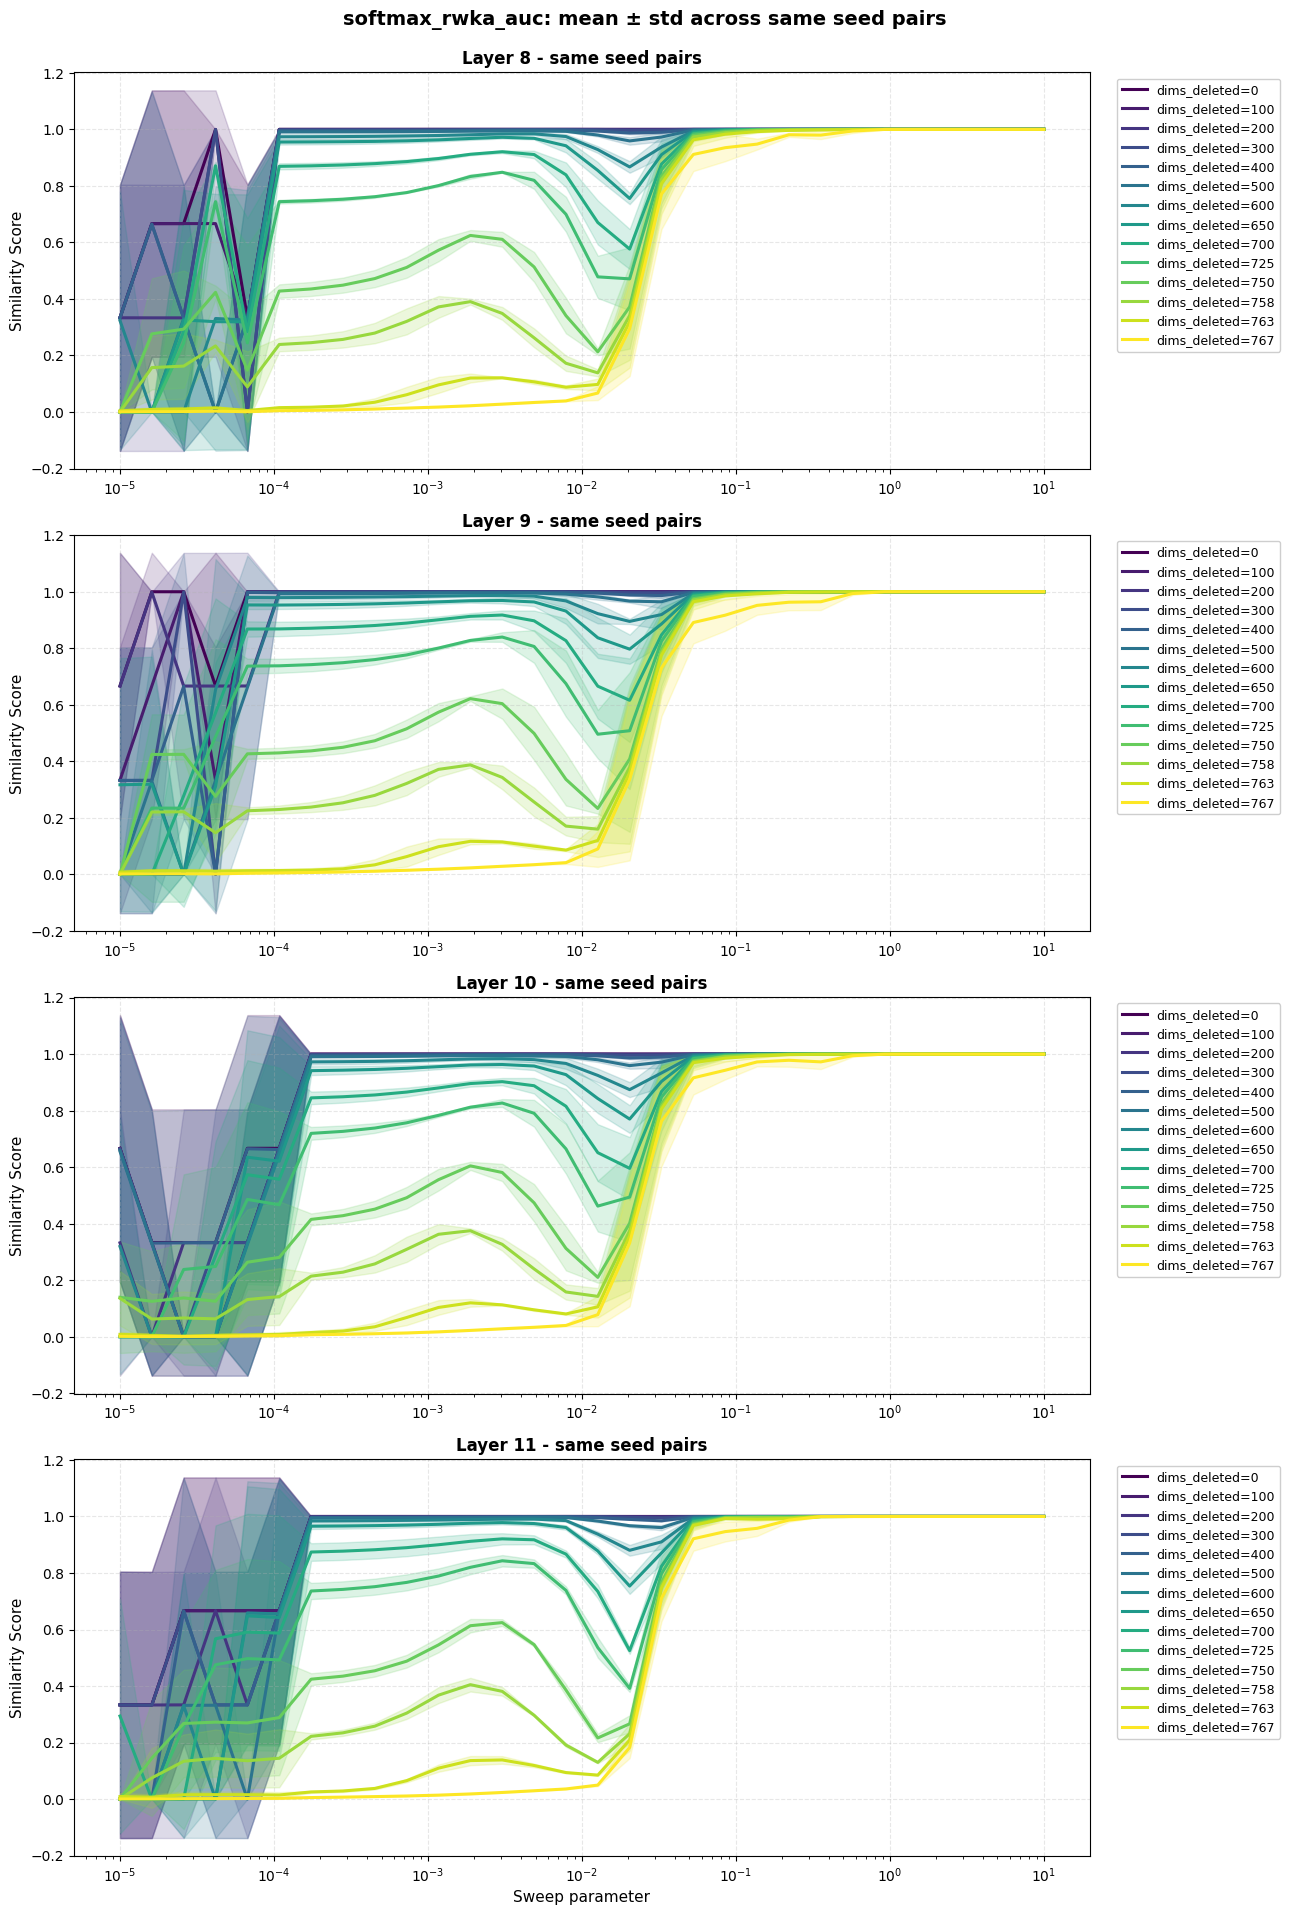

Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_fast_run/figures/aggregate_softmax_rwka_auc_different.png


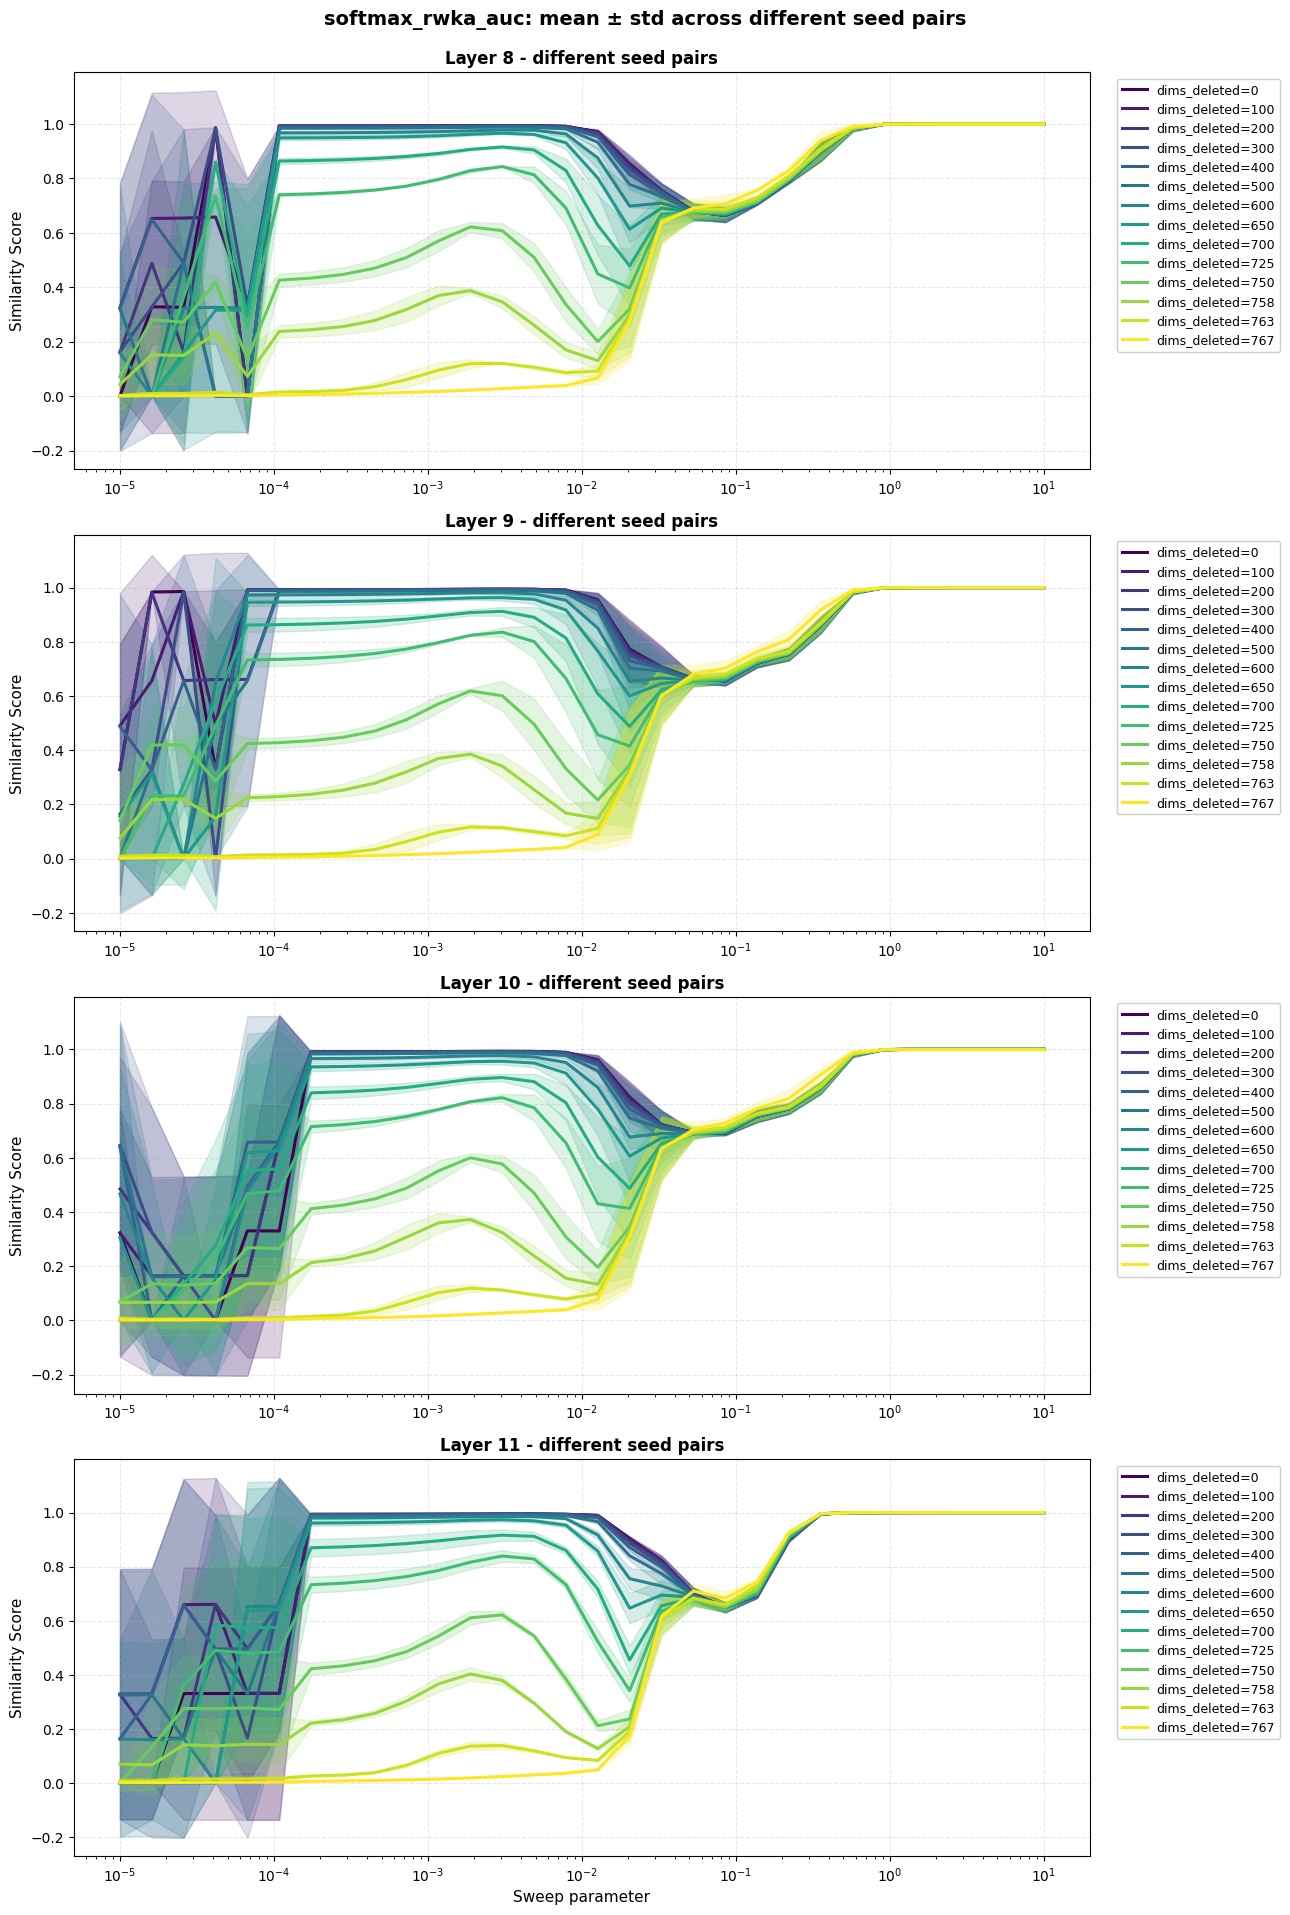

Aggregate comparison plots complete.


In [27]:
# ============================================================================
# Plot same-seed pairs vs different-seed pairs (mean +/- std)
# ============================================================================

metric_name = 'softmax_rwka_auc'  # Change to e.g., 'softmax_rwka_auc', 'mutual_knn_auc', 'cka_rbf_auc', 'rbf_rwka_auc', etc.
layers_for_aggregate = [8, 9, 10, 11]
results_base = "results/pca_deletion/pca_deletion_fast_run"

results_path = resources_path / results_base
figures_path = results_path / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

try:
    grouped_data = load_pairwise_aggregate_data(metric_name, layers_for_aggregate, results_base)
    print(f"Loaded aggregate pairwise data for {metric_name}")

    # Figure 1: same seed pairs
    save_path_same = figures_path / f"aggregate_{metric_name}_same.png"
    fig_same, axes_same = plot_aggregate_comparison(grouped_data, 'same', metric_name, save_path=save_path_same)
    if fig_same is not None:
        plt.show()

    # Figure 2: different seed pairs
    save_path_diff = figures_path / f"aggregate_{metric_name}_different.png"
    fig_diff, axes_diff = plot_aggregate_comparison(grouped_data, 'different', metric_name, save_path=save_path_diff)
    if fig_diff is not None:
        plt.show()

except Exception as e:
    print(f"Error loading or plotting aggregate pairwise data: {e}")


print("Aggregate comparison plots complete.")